# Phase 3: Salary Regression & The Linear Architecture
**Objective:** Implement Linear Regression from scratch using both the Normal Equation and Gradient Descent, compare it against industry standards, and audit the residuals.

### Step 1: The Implementation Pattern
We strictly follow: Load data -> define X/y -> split -> establish baseline -> train -> predict -> calculate metrics -> inspect residuals -> document[cite: 2].

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load Data (Simulating a Tech Salary dataset: Years of Experience & Skill Score -> Salary)
np.random.seed(42)
n_samples = 500
experience = np.random.uniform(1, 15, n_samples)
skill_score = np.random.uniform(50, 100, n_samples)

# The hidden real-world logic (Hypothesis: y = w1*x1 + w2*x2 + b + noise)
# Experience is worth $5000/yr, Skill is worth $1000/pt, base salary is $30,000
salary = (5000 * experience) + (1000 * skill_score) + 30000 + np.random.normal(0, 8000, n_samples)

X = np.column_stack((experience, skill_score))
y = salary

# 2. Strict Train/Test Split (Preventing Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Preprocessing (Standardization fit ONLY on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Establish a Baseline (Predict the mean)
baseline_pred = np.full(shape=y_test.shape, fill_value=np.mean(y_train))
baseline_mse = mean_squared_error(y_test, baseline_pred)
print(f"Baseline MSE (Predicting Mean): {baseline_mse:,.2f}")

Baseline MSE (Predicting Mean): 706,069,605.44


### Step 2: The Normal Equation (The Math Engine)
**The Formula:** $\theta=(X^{T}X)^{-1}X^{T}y$[cite: 2].
**Engineering Note:** To account for the intercept $b$ using pure matrix multiplication, we must append a column of strictly `1.0`s to our feature matrix $X$. This allows the equation to calculate $\theta$, where the first element is the intercept ($b$) and the rest are the weights ($w$).

In [5]:
# Append a column of 1s to the scaled features for the intercept
X_train_bias = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_bias = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# Calculate theta using the closed-form Normal Equation
# np.linalg.inv calculates the matrix inverse
theta_normal = np.linalg.inv(X_train_bias.T.dot(X_train_bias)).dot(X_train_bias.T).dot(y_train)

intercept_normal = theta_normal[0]
weights_normal = theta_normal[1:]

print("--- THETA NORMAL ---")
print(f"theta_normal: {theta_normal}")
print("--- NORMAL EQUATION RESULTS ---")
print(f"Intercept (b): {intercept_normal:,.2f}")
print(f"Weights (w): {weights_normal}")

--- THETA NORMAL ---
theta_normal: [145695.76623408  20090.41889427  14364.91132602]
--- NORMAL EQUATION RESULTS ---
Intercept (b): 145,695.77
Weights (w): [20090.41889427 14364.91132602]


### Step 3: Gradient Descent for Multiple Features
We now implement gradient descent for a small regression problem[cite: 2]. The formulas for updating $w$ and $b$ must be calculated simultaneously based on the gradient of the cost function[cite: 2].

In [6]:
def gradient_descent_multi(X, y, alpha=0.1, iterations=1000):
    m = len(y)
    # Initialize weights and intercept to zeros
    w = np.zeros(X.shape[1])
    b = 0.0
    
    for i in range(iterations):
        # Forward pass: y_hat = Xw + b
        y_hat = np.dot(X, w) + b
        
        # Calculate gradients based on Day 2 syllabus formulas
        # dw = (1/n) * sum((y_hat - y) * X)
        # db = (1/n) * sum(y_hat - y)
        dw = (1/m) * np.dot(X.T, (y_hat - y))
        db = (1/m) * np.sum(y_hat - y)
        
        # Update rules
        w = w - (alpha * dw)
        b = b - (alpha * db)
        
    return w, b

weights_gd, intercept_gd = gradient_descent_multi(X_train_scaled, y_train, alpha=0.1, iterations=500)

print("--- GRADIENT DESCENT RESULTS ---")
print(f"Intercept (b): {intercept_gd:,.2f}")
print(f"Weights (w): {weights_gd}")

--- GRADIENT DESCENT RESULTS ---
Intercept (b): 145,695.77
Weights (w): [20090.41889427 14364.91132602]


### Step 4: The Production Pipeline & Evaluation
We will train the sklearn equivalent and compare parameters/predictions[cite: 2]. Then, we calculate the core evaluation metrics (MSE, RMSE, MAE, $R^{2}$) and generate a Residual Plot to visually verify our straight-line hypothesis.

--- SKLEARN PRODUCTION RESULTS ---
Intercept (b): 145,695.77
Weights (w): [20090.41889427 14364.91132602]

--- FINAL EVALUATION METRIC TABLE ---
MSE:  70,610,137.16
RMSE: $8,402.98 (Average prediction error in dollars)
MAE:  $6,720.46
R^2:  0.8979


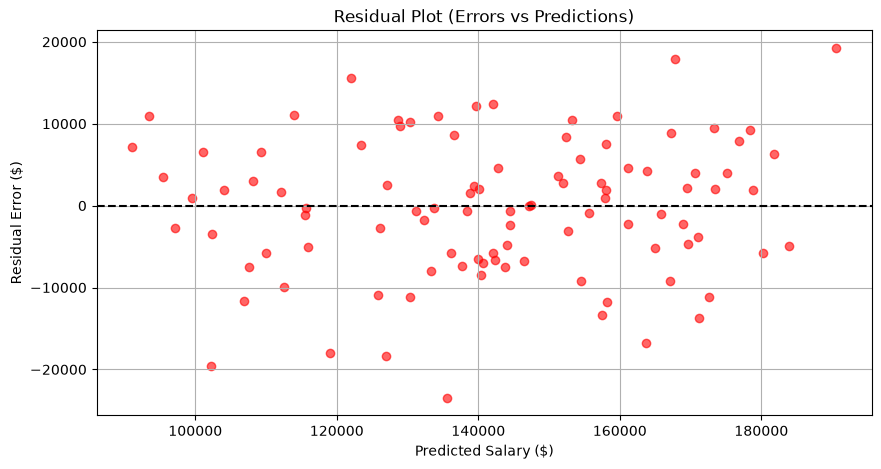

In [7]:
# 1. Sklearn Production Model
prod_model = LinearRegression()
prod_model.fit(X_train_scaled, y_train)

print("--- SKLEARN PRODUCTION RESULTS ---")
print(f"Intercept (b): {prod_model.intercept_:,.2f}")
print(f"Weights (w): {prod_model.coef_}")

# Notice how the weights and intercept are identical across all three methods!
# The math engine works flawlessly regardless of the approach.

# 2. Predictions & Metrics
y_pred = prod_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # RMSE has the same units as the target variable (Dollars)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred) # 1.0 is perfect, 0.0 is predicting the mean

print("\n--- FINAL EVALUATION METRIC TABLE ---")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: ${rmse:,.2f} (Average prediction error in dollars)")
print(f"MAE:  ${mae:,.2f}")
print(f"R^2:  {r2:.4f}")

# 3. Residual Plot Analysis
# Residual = actual value - predicted value
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.6, color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Residual Plot (Errors vs Predictions)")
plt.xlabel("Predicted Salary ($)")
plt.ylabel("Residual Error ($)")
plt.grid(True)
plt.show()